In [ ]:
pip install tensorflow

In [ ]:
import os
import numpy as np
import tensorflow as tf
import kagglehub
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models,regularizers
from sklearn.metrics import classification_report

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("Using Device: GPU")
else:
    print("Using Device: CPU")


TensorFlow Version: 2.20.0
Using Device: GPU


In [ ]:
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset Path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset Path: /kaggle/input/chest-xray-pneumonia


In [ ]:
TRAIN_PATH = os.path.join(
    path,
    "chest_xray",
    "train"
)

VAL_PATH = os.path.join(
    path,
    "chest_xray",
    "val"
)

TEST_PATH = os.path.join(
    path,
    "chest_xray",
    "test"
)

In [ ]:
IMG_SIZE = (128, 128)

BATCH_SIZE = 32

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42
)

Found 5216 files belonging to 2 classes.


In [ ]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 16 files belonging to 2 classes.


In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

Found 624 files belonging to 2 classes.


In [ ]:
class_names = train_dataset.class_names

num_classes = len(class_names)

print("\nClass Names:", class_names)

print("Number of Classes:", num_classes)



Class Names: ['NORMAL', 'PNEUMONIA']
Number of Classes: 2


In [ ]:
print("\nDataset Information:")

print(
    "Training Batches:",
    tf.data.experimental.cardinality(
        train_dataset
    ).numpy()
)

print(
    "Validation Batches:",
    tf.data.experimental.cardinality(
        val_dataset
    ).numpy()
)

print(
    "Testing Batches:",
    tf.data.experimental.cardinality(
        test_dataset
    ).numpy()
)


Dataset Information:
Training Batches: 163
Validation Batches: 1
Testing Batches: 20


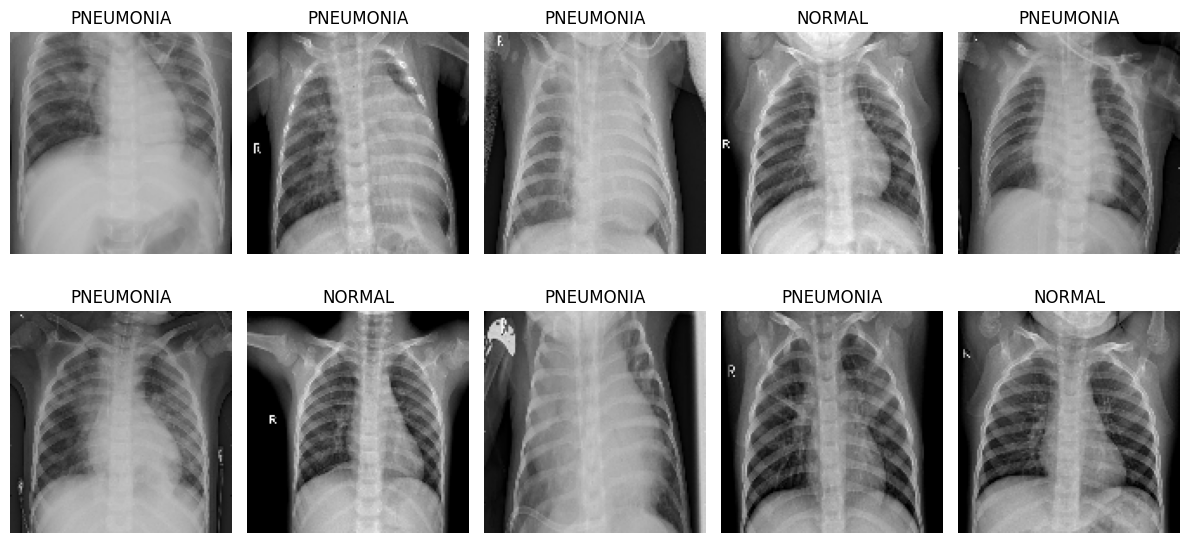

In [ ]:
images, labels = next(iter(train_dataset))

plt.figure(figsize=(12, 6))

for i in range(min(10, len(images))):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].numpy().astype("uint8")
    )

    plt.title(
        class_names[labels[i].numpy()]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.05
    ),

    layers.RandomZoom(
        0.1
    )
])

In [ ]:
train_dataset = train_dataset.map(
    lambda images, labels:
        (
            data_augmentation(
                images,
                training=True
            ),
            labels
        ),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
normalization_layer = layers.Rescaling(
    scale=1.0 / 127.5,
    offset=-1
)


train_dataset = train_dataset.map(
    lambda images, labels:
        (
            normalization_layer(images),
            labels
        ),
    num_parallel_calls=tf.data.AUTOTUNE
)


val_dataset = val_dataset.map(
    lambda images, labels:
        (
            normalization_layer(images),
            labels
        ),
    num_parallel_calls=tf.data.AUTOTUNE
)


test_dataset = test_dataset.map(
    lambda images, labels:
        (
            normalization_layer(images),
            labels
        ),
    num_parallel_calls=tf.data.AUTOTUNE
)


In [ ]:

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
# ============================================================
# 16. Custom CNN Model
# ============================================================

model = models.Sequential([

    layers.Input(
        shape=(128, 128, 3)
    ),


    # --------------------------------------------------------
    # CNN Block 1
    # --------------------------------------------------------

    layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(
            0.0001
        )
    ),

    layers.ReLU(),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        pool_size=2
    ),
     # --------------------------------------------------------
    # CNN Block 2
    # --------------------------------------------------------

    layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(
            0.0001
        )
    ),

    layers.ReLU(),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        pool_size=2
    ),
     # --------------------------------------------------------
    # CNN Block 3
    # --------------------------------------------------------

    layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(
            0.0001
        )
    ),

    layers.ReLU(),

    layers.BatchNormalization(),

    layers.MaxPooling2D(
        pool_size=2
    ),
    # --------------------------------------------------------
    # Classifier
    # --------------------------------------------------------

    layers.Flatten(),


    layers.Dense(
        128,
        kernel_regularizer=regularizers.l2(
            0.0001
        )
    ),

    layers.ReLU(),

    layers.Dropout(
        0.5
    ),


    layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(
            0.0001
        )
    ),

    layers.ReLU(),

    layers.Dropout(
        0.5
    ),
        # --------------------------------------------------------
    # Output Layer
    # --------------------------------------------------------

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])




In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,296,962 (16.39 MB)

 Trainable params: 4,296,514 (16.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
learning_rate = 0.001

optimizer = tf.keras.optimizers.Adam(
    learning_rate=learning_rate
)

In [ ]:
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
epochs = 25

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs
)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 355ms/step - accuracy: 0.7512 - loss: 1.1783 - val_accuracy: 0.5000 - val_loss: 40.9059
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 60s 265ms/step - accuracy: 0.7515 - loss: 0.5085 - val_accuracy: 0.5000 - val_loss: 36.0845
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 271ms/step - accuracy: 0.7918 - loss: 0.4549 - val_accuracy: 0.6875 - val_loss: 1.5900
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 271ms/step - accuracy: 0.7880 - loss: 0.4715 - val_accuracy: 0.6250 - val_loss: 0.6960
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 81s 264ms/step - accuracy: 0.8424 - loss: 0.4491 - val_accuracy: 0.8125 - val_loss: 0.5289
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 272ms/step - accuracy: 0.8397 - loss: 0.4182 - val_accuracy: 0.7500 - val_loss: 0.5733
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 267ms/step - accuracy: 0.8658 - loss: 0.4195 - val_accuracy: 0.7500 - val_loss: 0.6362
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 277ms/step - accuracy: 0.8760 - loss:

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("\nTest Results:")

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - accuracy: 0.8798 - loss: 0.3858

Test Results:
Test Loss: 0.3858
Test Accuracy: 87.98%


In [ ]:
y_true = []

y_pred = []


for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )


y_true = np.array(y_true)

y_pred = np.array(y_pred)


In [ ]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)




Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.89      0.77      0.83       234
   PNEUMONIA       0.87      0.94      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624




Confusion Matrix:

[[181  53]
 [ 22 368]]


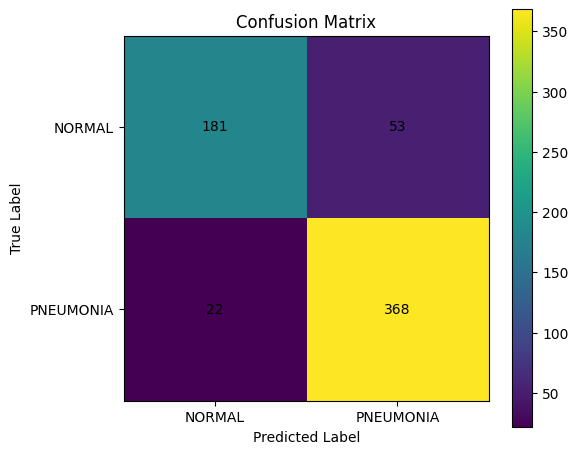

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix:\n")
print(cm)
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(num_classes),
    class_names
)

plt.yticks(
    range(num_classes),
    class_names
)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
model.save(
    "chest_xray_custom_cnn.keras"
)

print(
    "\nModel saved successfully!"
)


Model saved successfully!
